## PART 5: FEATURE EVALUATION AND SELECTION

This section systematically evaluates both original and newly engineered features to identify those that provide the most valuable information for future modeling. We will consider statistical relationships, potential redundancies, and overall analytical utility.

### Reconstructing `df_model` with all Engineered Features

To ensure a comprehensive evaluation, we first need to re-apply all cleaning, preprocessing, and feature engineering steps from `Part 3` and `Part 4` to the original dataset. This will create a `df_model` DataFrame that contains every feature, including the advanced ones, ready for selection.

In [15]:
# Import necessary libraries
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import chi2_contingency     # Chi-square test of independence
from scipy.stats import mannwhitneyu      # Mann-Whitney U test
from scipy import stats     
from sklearn.feature_selection import mutual_info_classif    # Mutual Information


In [16]:
# Re-load the original dataset to start clean
df_model = pd.read_csv('../data/train_u6lujuX_CVtuZ9i.csv')

# --- PART 3: Data Cleaning & Basic Feature Engineering ---

def wrangle(df):
    """Clean loan data in one pass and return a cleaned copy."""
    df_copy = df.copy()

    # Standardize Dependents values
    df_copy['Dependents'] = df_copy['Dependents'].replace('3+', '3')

    # Categorical mode imputation
    for col in ['Gender', 'Married', 'Self_Employed']:
        col_mode = df_copy[col].mode()[0]
        df_copy[col] = df_copy[col].fillna(col_mode)

    # Specific column imputations
    df_copy['Dependents'] = df_copy['Dependents'].fillna(df_copy['Dependents'].mode()[0])
    df_copy['Credit_History'] = df_copy['Credit_History'].fillna(df_copy['Credit_History'].mode()[0])
    df_copy['LoanAmount'] = df_copy['LoanAmount'].fillna(df_copy['LoanAmount'].median())
    df_copy['Loan_Amount_Term'] = df_copy['Loan_Amount_Term'].fillna(df_copy['Loan_Amount_Term'].mode()[0])

    # Final type corrections
    df_copy['Dependents'] = df_copy['Dependents'].astype(int)
    df_copy['Credit_History'] = df_copy['Credit_History'].astype(int)
    df_copy['Loan_Amount_Term'] = df_copy['Loan_Amount_Term'].astype(int)

    # Optional cleanup
    df_copy = df_copy.drop_duplicates()

    # Rename columns for clarity and consistency
    df_copy = df_copy.rename(columns={
        'ApplicantIncome': 'Applicant_Income',
        'CoapplicantIncome': 'Coapplicant_Income',
        'LoanAmount': 'Loan_Amount'
    })

    return df_copy

# Apply initial wrangling
df_model = wrangle(df_model)

# Remove irrelevant features
df_model = df_model.drop(columns=["Loan_ID"])

# Create basic engineered features
df_model['Total_Income'] = df_model['Applicant_Income'] + df_model['Coapplicant_Income']
df_model["Monthly_Repayment"] = (df_model["Loan_Amount"] * 1000) / df_model["Loan_Amount_Term"]
df_model["Balance_Income"] = df_model["Total_Income"] - df_model["Monthly_Repayment"]
df_model["Loan_Income_Ratio"] = (df_model["Loan_Amount"] * 1000) / df_model["Total_Income"]

# Outlier capping using IQR
def iqr_cap(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    capped = series.clip(lower=lower, upper=upper)
    return capped

continuous_cols_to_cap = ["Applicant_Income", "Coapplicant_Income", "Loan_Amount",
                            "Total_Income", "Monthly_Repayment", "Balance_Income", "Loan_Income_Ratio"]
for col in continuous_cols_to_cap:
    df_model[col] = iqr_cap(df_model[col])

# Drop highly collinear / redundant features after capping
columns_to_drop_redundant = [
    "Applicant_Income",
    "Coapplicant_Income",
    "Loan_Amount",
    "Balance_Income",
]
df_model.drop(columns=[col for col in columns_to_drop_redundant if col in df_model.columns], inplace=True)

# Feature Encoding
df_model["Loan_Status"] = df_model["Loan_Status"].map({"Y": 1, "N": 0})
binary_cols_map = {
    "Gender": {"Male": 1, "Female": 0},
    "Married": {"Yes": 1, "No": 0},
    "Self_Employed": {"Yes": 1, "No": 0},
    "Education": {"Graduate": 1, "Not Graduate": 0}
}
for col, mapping in binary_cols_map.items():
    df_model[col] = df_model[col].map(mapping)
df_model = pd.get_dummies(df_model, columns=["Property_Area"], drop_first=True, dtype=int)

# --- PART 4: ADVANCED FEATURE ENGINEERING ---

# 1. Loan_Term_Years
df_model['Loan_Term_Years'] = df_model['Loan_Amount_Term'] / 12

# 2. Income_Per_Person (requires original Dependents + Applicant/Coapplicant counts)
# Note: Dependents was already cleaned and converted to int in wrangle function.
# We assume Dependents now includes only true dependents, and add 1 for the applicant.
# If Dependents was 3+, it's now 3. So total people = Dependents + 1 (applicant)
df_model['Income_Per_Person'] = df_model['Total_Income'] / (df_model['Dependents'] + 1)

# 3. Repayment_Burden_Pct
df_model['Repayment_Burden_Pct'] = (df_model['Monthly_Repayment'] / (df_model['Total_Income'] / 12 + 1e-6)) * 100

# 4. Log_Total_Income
df_model['Log_Total_Income'] = np.log1p(df_model['Total_Income'])

# 5. Income_to_LoanTerm_Interaction
df_model['Income_to_LoanTerm_Interaction'] = df_model['Total_Income'] * df_model['Loan_Amount_Term']

# 6. Income_Band
df_model['Income_Band'] = pd.qcut(df_model['Total_Income'], q=4, labels=['Low Income', 'Lower-Middle Income', 'Upper-Middle Income', 'High Income'])

# 7. Repayment_Risk_Category
# Using existing Loan_Income_Ratio
percentiles_risk = df_model['Loan_Income_Ratio'].quantile([0.25, 0.75])
def assign_risk_category(ratio):
    if ratio <= percentiles_risk[0.25]:
        return 'Low Risk'
    elif ratio >= percentiles_risk[0.75]:
        return 'High Risk'
    else:
        return 'Moderate Risk'
df_model['Repayment_Risk_Category'] = df_model['Loan_Income_Ratio'].apply(assign_risk_category)

# 8. Credit_Profile_Segment
def assign_credit_profile_segment(row):
    if row['Credit_History'] == 0:
        return 'Credit-Challenged'
    elif row['Credit_History'] == 1 and row['Repayment_Burden_Pct'] < 35:
        return 'Prime Capacity'
    else:
        return 'Credit-Positive but Stretched'
df_model['Credit_Profile_Segment'] = df_model.apply(assign_credit_profile_segment, axis=1)


# Display the head and info of the fully prepared DataFrame
print("df_model created with all engineered features.")
display(df_model.head())
df_model.info()

df_model created with all engineered features.


,Gender,Married,Dependents,Education,Self_Employed,Loan_Amount_Term,Credit_History,Loan_Status,Total_Income,Monthly_Repayment,...,Property_Area_Semiurban,Property_Area_Urban,Loan_Term_Years,Income_Per_Person,Repayment_Burden_Pct,Log_Total_Income,Income_to_LoanTerm_Interaction,Income_Band,Repayment_Risk_Category,Credit_Profile_Segment
0,1,0,0,1,0,360,1,1,5849.0,355.555556,...,0,1,30.0,5849.0,72.946942,8.674197,2105640.0,Upper-Middle Income,Moderate Risk,Credit-Positive but Stretched
1,1,1,1,1,0,360,1,0,6091.0,355.555556,...,0,0,30.0,3045.5,70.048706,8.714732,2192760.0,Upper-Middle Income,Moderate Risk,Credit-Positive but Stretched
2,1,1,0,1,1,360,1,1,3000.0,183.333333,...,0,1,30.0,3000.0,73.333333,8.006701,1080000.0,Low Income,Moderate Risk,Credit-Positive but Stretched
3,1,1,0,0,0,360,1,1,4941.0,333.333333,...,0,1,30.0,4941.0,80.955272,8.505525,1778760.0,Lower-Middle Income,Moderate Risk,Credit-Positive but Stretched
4,1,0,0,1,0,360,1,1,6000.0,391.666667,...,0,1,30.0,6000.0,78.333333,8.699681,2160000.0,Upper-Middle Income,Moderate Risk,Credit-Positive but Stretched


<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   Gender                          614 non-null    int64   
 1   Married                         614 non-null    int64   
 2   Dependents                      614 non-null    int64   
 3   Education                       614 non-null    int64   
 4   Self_Employed                   614 non-null    int64   
 5   Loan_Amount_Term                614 non-null    int64   
 6   Credit_History                  614 non-null    int64   
 7   Loan_Status                     614 non-null    int64   
 8   Total_Income                    614 non-null    float64 
 9   Monthly_Repayment               614 non-null    float64 
 10  Loan_Income_Ratio               614 non-null    float64 
 11  Property_Area_Semiurban         614 non-null    int64   
 12  Property_Area_Urban             6

### Correlation Analysis of All Features in `df_model`

We will now compute and visualize the correlation matrix for all numerical features in our comprehensive `df_model`. This helps in identifying potential multicollinearity and understanding relationships between features, including the newly engineered ones, and the target variable `Loan_Status`.

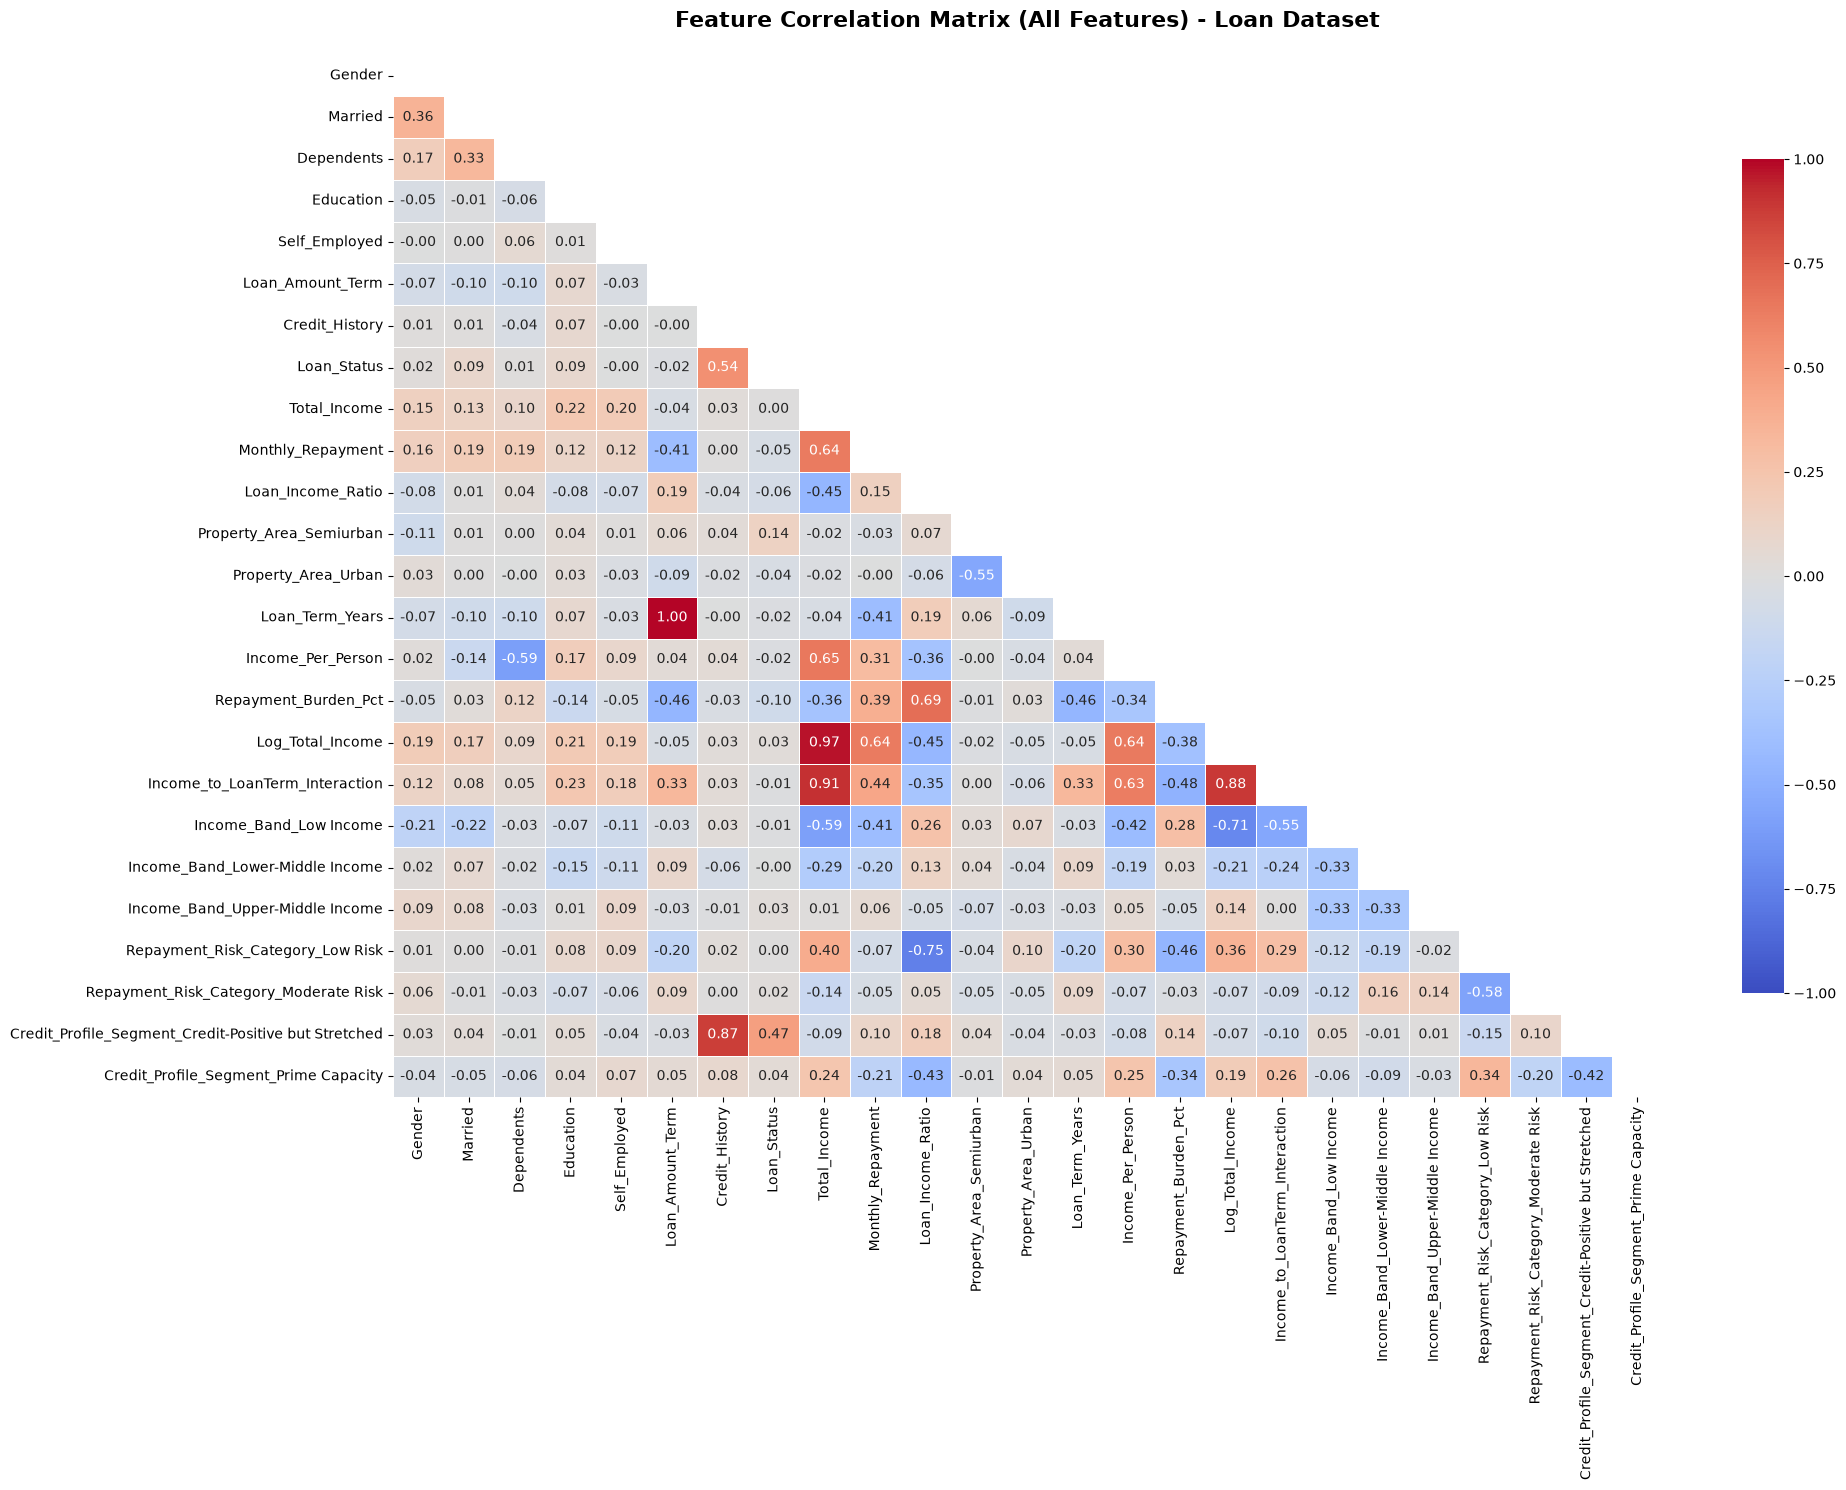


=== HIGHLY CORRELATED / REDUNDANT FEATURE PAIRS (|r| > 0.75) ===
• Loan_Term_Years <---> Loan_Amount_Term: Correlation = 1.00
• Log_Total_Income <---> Total_Income: Correlation = 0.97
• Income_to_LoanTerm_Interaction <---> Total_Income: Correlation = 0.91
• Income_to_LoanTerm_Interaction <---> Log_Total_Income: Correlation = 0.88
• Repayment_Risk_Category_Low Risk <---> Loan_Income_Ratio: Correlation = -0.75
• Credit_Profile_Segment_Credit-Positive but Stretched <---> Credit_History: Correlation = 0.87


In [17]:
# Convert categorical features (Income_Band, Repayment_Risk_Category, Credit_Profile_Segment)
# to numerical representations for correlation calculation.
# We will use one-hot encoding for `Income_Band`, `Repayment_Risk_Category`, and `Credit_Profile_Segment`.
# First, convert 'Income_Band' from category to object type to ensure get_dummies works as expected.

df_model_corr = df_model.copy()
df_model_corr['Income_Band'] = df_model_corr['Income_Band'].astype(str)

# One-hot encode the categorical engineered features
df_model_corr = pd.get_dummies(df_model_corr, columns=['Income_Band', 'Repayment_Risk_Category', 'Credit_Profile_Segment'], drop_first=True, dtype=int)

# Ensure all columns are numeric for correlation calculation
df_model_corr = df_model_corr.select_dtypes(include=[np.number])

# Compute the correlation matrix
corr_matrix_all = df_model_corr.corr()

# Plot Correlation Heatmap
plt.figure(figsize=(20, 15)) # Adjust figure size for better readability with more features
mask = np.triu(np.ones_like(corr_matrix_all, dtype=bool))  # Mask upper triangle

sns.heatmap(
    corr_matrix_all,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    mask=mask,
    cbar_kws={"shrink": 0.8},
)

plt.title(
    "Feature Correlation Matrix (All Features) - Loan Dataset",
    fontsize=16,
    fontweight="bold",
    pad=20,
)
plt.tight_layout()
plt.show()

# Detect highly correlated feature pairs (|r| > 0.75 excluding self-correlation)
high_corr_pairs_all = []
for i in range(len(corr_matrix_all.columns)):
    for j in range(i):
        if abs(corr_matrix_all.iloc[i, j]) > 0.75: # Threshold for high correlation
            col1 = corr_matrix_all.columns[i]
            col2 = corr_matrix_all.columns[j]
            val = corr_matrix_all.iloc[i, j]
            high_corr_pairs_all.append((col1, col2, val))

print("\n=== HIGHLY CORRELATED / REDUNDANT FEATURE PAIRS (|r| > 0.75) ===")
if high_corr_pairs_all:
    for col1, col2, val in high_corr_pairs_all:
        print(f"• {col1} <---> {col2}: Correlation = {val:.2f}")
else:
    print("No severe multicollinearity detected (|r| <= 0.75).")


### Mutual Information Scores for Feature Importance

Mutual Information (MI) measures the dependency between two variables. It quantifies the 'amount of information' obtained about one variable by observing the other. Unlike correlation, MI can capture non-linear relationships, making it a powerful tool for feature selection. A higher MI score indicates a stronger dependency between the feature and the target variable (`Loan_Status`).

=== Mutual Information Scores (Relative to Loan_Status) ===
Credit_Profile_Segment            0.142407
Credit_History                    0.142400
Loan_Amount_Term                  0.012432
Loan_Term_Years                   0.012231
Income_to_LoanTerm_Interaction    0.011527
Property_Area_Semiurban           0.009559
Married                           0.004130
Education                         0.003591
Dependents                        0.002618
Property_Area_Urban               0.000944
Income_Band                       0.000517
Repayment_Risk_Category           0.000287
Gender                            0.000161
Self_Employed                     0.000007
Total_Income                      0.000000
Loan_Income_Ratio                 0.000000
Monthly_Repayment                 0.000000
Log_Total_Income                  0.000000
Income_Per_Person                 0.000000
Repayment_Burden_Pct              0.000000
dtype: float64


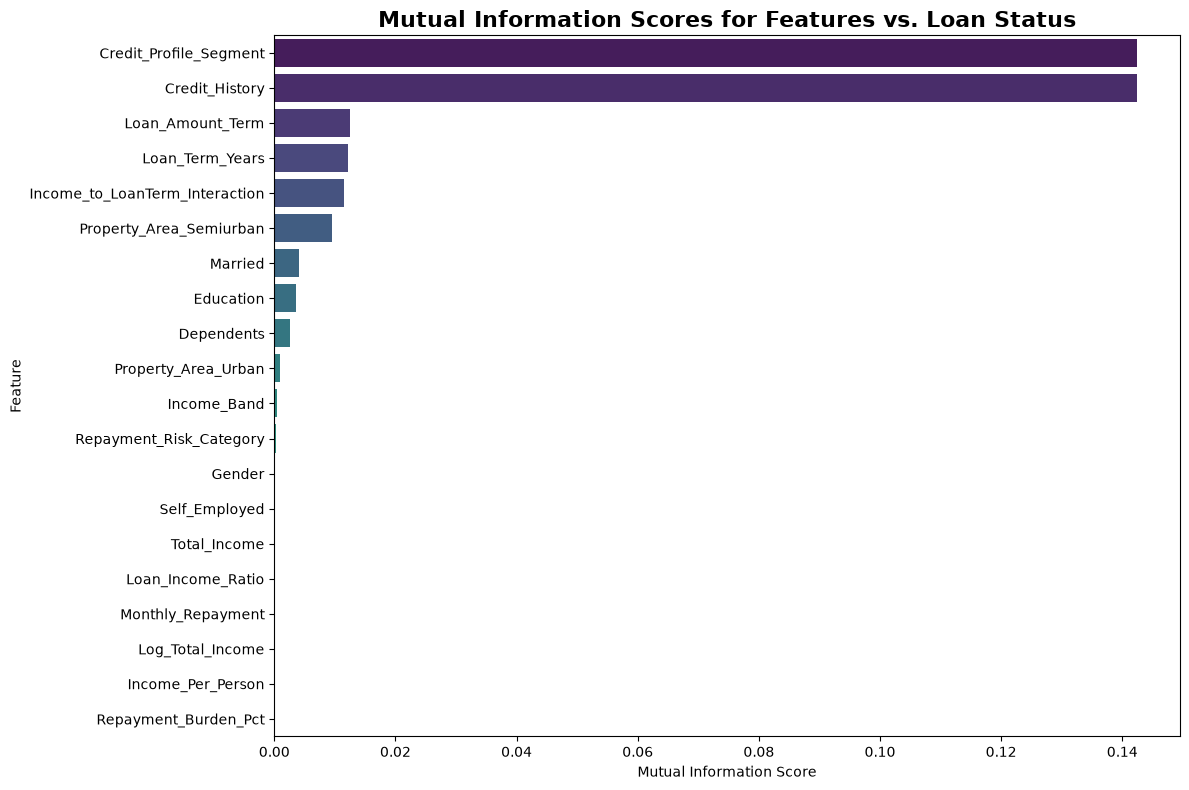

In [18]:
# Prepare the data for Mutual Information calculation
# Separate features (X) and target (y)
X_mi = df_model.drop(columns=['Loan_Status']).copy()
y_mi = df_model['Loan_Status']

# Encode every non-numeric column robustly (object/category/string/bool)
non_numeric_cols = X_mi.select_dtypes(exclude=[np.number]).columns
for col in non_numeric_cols:
    le = LabelEncoder()
    X_mi[col] = le.fit_transform(X_mi[col].astype(str))

# Safety check: all features must now be numeric
remaining_non_numeric = X_mi.select_dtypes(exclude=[np.number]).columns.tolist()
if remaining_non_numeric:
    raise ValueError(f"Non-numeric columns remain after encoding: {remaining_non_numeric}")

# Determine which features are discrete
# Integer-like columns are treated as discrete, float columns as continuous
discrete_features_mask = np.array([pd.api.types.is_integer_dtype(X_mi[col]) for col in X_mi.columns])

# Calculate Mutual Information scores
mi_scores = mutual_info_classif(
    X_mi,
    y_mi,
    discrete_features=discrete_features_mask,
    random_state=42
)

# Create a Series for better visualization and sorting
mi_series = pd.Series(mi_scores, index=X_mi.columns)

# Sort the features by MI score in descending order
mi_series = mi_series.sort_values(ascending=False)

print("=== Mutual Information Scores (Relative to Loan_Status) ===")
print(mi_series)

# Plotting the Mutual Information scores
plt.figure(figsize=(12, 8))
sns.barplot(x=mi_series.values, y=mi_series.index, palette='viridis')
plt.title('Mutual Information Scores for Features vs. Loan Status', fontsize=16, fontweight='bold')
plt.xlabel('Mutual Information Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Interpretation of Mutual Information Scores

The Mutual Information scores provide valuable insights into the predictive power of each feature, including non-linear relationships. We can observe:

*   Features with high MI scores are strongly related to `Loan_Status` and are likely to be good predictors.
*   Features with low MI scores indicate less dependency on `Loan_Status` and might be less useful for modeling.

This analysis, combined with the correlation matrix, will guide our final feature selection. We aim to keep features that show strong relationships with the target variable, minimize redundancy, and align with business interpretability.

## Feature Evaluation and Selection Summary

The following decisions are based on:
- Correlation analysis (including high-correlation pairs with threshold $|r| > 0.75$).
- Mutual Information (MI) with respect to `Loan_Status`.
- Redundancy and multicollinearity checks.
- Domain/business interpretability.
- Data leakage review.

| Feature Evaluated | Method Used | Evidence Obtained | Decision | Why Decision Is Appropriate |
|---|---|---|---|---|
| `Credit_History` | MI + prior Chi-square evidence + correlation with target | MI = **0.142400** (top signal), strong target relationship from prior tests | **Retained** | Strongest stable predictor, directly relevant to repayment behavior risk |
| `Credit_Profile_Segment` | MI + redundancy check vs `Credit_History` | MI = **0.142407** (top), but highly correlated with `Credit_History` ($r = 0.87$) and derived partly from it | **Removed** (for primary parsimonious model) | Prevents duplicated signal and unnecessary complexity; keep as optional business segmentation feature |
| `Loan_Amount_Term` | MI + redundancy check | MI = **0.012432**, non-zero signal | **Retained** | Keeps the original informative variable with direct business meaning |
| `Loan_Term_Years` | Correlation redundancy check + MI | Perfect duplicate of term in another unit ($r = 1.00$ with `Loan_Amount_Term`), MI very similar | **Removed** | Deterministic duplicate; removing reduces multicollinearity with no information loss |
| `Total_Income` | MI + correlation structure | MI = **0.000000**; strongly correlated with transformed derivatives | **Removed** | Adds little direct information in current setup and contributes to redundancy |
| `Log_Total_Income` | MI + redundancy check | MI = **0.000000**; highly correlated with `Total_Income` ($r = 0.97$) | **Removed** | No incremental predictive gain and high redundancy |
| `Income_to_LoanTerm_Interaction` | MI + correlation check | MI = **0.011527** (useful but modest), correlated with income features ($r = 0.91$ with `Total_Income`) | **Retained** | Captures interaction effects missed by single variables; useful for non-linear models |
| `Loan_Income_Ratio` | MI + correlation | MI = **0.000000**; relationship mostly captured by derived categorical/profile features | **Removed** | Limited standalone analytical value for this modelling stage |
| `Repayment_Risk_Category` | MI + correlation with source ratio | MI = **0.000287** (very low), strong inverse association with source ratio dummy (e.g., Low Risk vs ratio $r = -0.75$) | **Removed** | Very low incremental signal and derivative redundancy |
| `Repayment_Burden_Pct` | MI + dependence check | MI = **0.000000**; used inside engineered segment rules | **Removed** | Weak standalone value; signal already absorbed by stronger variables |
| `Income_Band` | MI | MI = **0.000517** (very low) | **Removed** | Coarse binning did not improve information content |
| `Income_Per_Person` | MI | MI = **0.000000** | **Removed** | No measurable dependency with target in current dataset |
| `Property_Area_Semiurban` | MI + EDA context | MI = **0.009559**, consistent with earlier approval-rate differences by area | **Retained** | Carries useful location-related signal and is interpretable |
| `Property_Area_Urban` | MI + domain | MI = **0.000944** (weak) | **Retained** (monitor) | Kept for complete area representation and potential interaction effects |
| `Married` | MI + prior EDA | MI = **0.004130**, previously showed meaningful approval-rate gap | **Retained** | Moderate but interpretable socio-demographic signal |
| `Education` | MI + prior test evidence | MI = **0.003591**, supported by earlier repayment distribution differences | **Retained** | Adds interpretable applicant-profile information |
| `Dependents` | MI + domain | MI = **0.002618** (low but non-zero) | **Retained** (monitor) | Potentially useful in interaction effects and affordability context |
| `Gender` | MI | MI = **0.000161** | **Removed** | Negligible predictive contribution in this dataset |
| `Self_Employed` | MI | MI = **0.000007** | **Removed** | Near-zero information contribution |
| `Monthly_Repayment` | MI + redundancy context | MI = **0.000000**; derivative of amount and term | **Removed** | Redundant derivative with no standalone MI gain |

### Leakage Check
- No selected feature is directly derived from `Loan_Status`.
- Engineered variables were built only from applicant/application attributes available at decision time.
- `Credit_Profile_Segment` was removed from the primary model partly to avoid over-engineered duplication of `Credit_History`.

### Final Selected Feature Set (Primary Modelling)
- `Credit_History`
- `Loan_Amount_Term`
- `Income_to_LoanTerm_Interaction`
- `Property_Area_Semiurban`
- `Property_Area_Urban`
- `Married`
- `Education`
- `Dependents`

### Notes
- Retained variables marked "monitor" should be validated during model training using cross-validation and permutation importance.
- Removed variables may still be useful for business reporting even if excluded from the predictive baseline model.

## Week 2 Dataset Refinement (Using Advanced Findings)

Based on Part 4 and Part 5 evidence, this refinement updates Week 2 outputs by:
- Adding a meaningful engineered flag: `Is_Standard_Term` (captures the discovered 360-month term concentration pattern).
- Keeping informative and interpretable predictors.
- Removing redundant or low-value features identified by MI and multicollinearity checks.
- Producing both a refined unscaled dataset and a refined ML-ready scaled dataset.

In [22]:
# Build refined Week 2 datasets from df_model based on advanced feature evidence

refined_df = df_model.copy()

# New meaningful engineered feature from advanced EDA findings
# 1 = standard 360-month term, 0 = non-standard term
refined_df['Is_Standard_Term'] = (refined_df['Loan_Amount_Term'] == 360).astype(int)

# Features to remove (low MI, redundancy, or duplicate transformation)
features_to_remove = [
    'Loan_Term_Years',                    # perfect duplicate of Loan_Amount_Term in years
    'Total_Income',                       # redundant with income-derived terms and low MI
    'Log_Total_Income',                   # highly collinear with Total_Income and low MI
    'Loan_Income_Ratio',                  # low MI in current setup
    'Repayment_Risk_Category',            # derivative categorical with very low MI
    'Repayment_Burden_Pct',               # low standalone MI
    'Income_Band',                        # coarse bins with very low MI
    'Income_Per_Person',                  # low MI
    'Gender',                             # near-zero MI
    'Self_Employed',                      # near-zero MI
    'Monthly_Repayment',                  # derivative with low incremental value
    'Credit_Profile_Segment'              # high correlation / overlap with Credit_History
]

refined_df = refined_df.drop(columns=[c for c in features_to_remove if c in refined_df.columns])

# Final selected feature set for modelling (plus target)
selected_features = [
    'Credit_History',
    'Loan_Amount_Term',
    'Is_Standard_Term',
    'Income_to_LoanTerm_Interaction',
    'Property_Area_Semiurban',
    'Property_Area_Urban',
    'Married',
    'Education',
    'Dependents'
]

target_col = 'Loan_Status'

# Keep only selected features and target
missing_features = [c for c in selected_features if c not in refined_df.columns]
if missing_features:
    raise ValueError(f"Missing expected selected features: {missing_features}")

refined_cleaned = refined_df[selected_features + [target_col]].copy()

# Create ML-ready version with RobustScaler on the requested columns
refined_ml_ready = refined_cleaned.copy()
scale_cols = ['Loan_Amount_Term', 'Income_to_LoanTerm_Interaction']

scaler = RobustScaler()
refined_ml_ready[scale_cols] = scaler.fit_transform(refined_ml_ready[scale_cols])

# Save refined outputs
output_dir = '../data/processed'
os.makedirs(output_dir, exist_ok=True)

cleaned_path = os.path.join(output_dir, 'loan_prediction_refined_cleaned.csv')
ml_ready_path = os.path.join(output_dir, 'final_modelling_dataset.csv')

refined_cleaned.to_csv(cleaned_path, index=False)
refined_ml_ready.to_csv(ml_ready_path, index=False)

print('Refinement complete.')
print(f'Refined cleaned dataset saved to: {cleaned_path}')
print(f'Refined ML-ready dataset saved to: {ml_ready_path}')
print('\nRefined cleaned shape:', refined_cleaned.shape)
print('Final Modelling Dataset:', refined_ml_ready.shape)

print('\nScaled columns preview (RobustScaler applied):')
display(refined_ml_ready[scale_cols].describe().T)

display(refined_cleaned.head())

Refinement complete.
Refined cleaned dataset saved to: ../data/processed\loan_prediction_refined_cleaned.csv
Refined ML-ready dataset saved to: ../data/processed\final_modelling_dataset.csv

Refined cleaned shape: (614, 10)
Final Modelling Dataset: (614, 10)

Scaled columns preview (RobustScaler applied):


,count,mean,std,min,25%,50%,75%,max
Loan_Amount_Term,614.0,-17.589577,64.428629,-348.000000,0.000000,0.0,0.000000,120.000000
Income_to_LoanTerm_Interaction,614.0,0.223124,0.958766,-1.617754,-0.435591,0.0,0.564409,3.784293


,Credit_History,Loan_Amount_Term,Is_Standard_Term,Income_to_LoanTerm_Interaction,Property_Area_Semiurban,Property_Area_Urban,Married,Education,Dependents,Loan_Status
0,1,360,1,2105640.0,0,1,0,1,0,1
1,1,360,1,2192760.0,0,0,1,1,1,0
2,1,360,1,1080000.0,0,1,1,1,0,1
3,1,360,1,1778760.0,0,1,1,0,0,1
4,1,360,1,2160000.0,0,1,0,1,0,1


In [23]:
refined_ml_ready.head()

,Credit_History,Loan_Amount_Term,Is_Standard_Term,Income_to_LoanTerm_Interaction,Property_Area_Semiurban,Property_Area_Urban,Married,Education,Dependents,Loan_Status
0,1,0.0,1,0.216526,0,1,0,1,0,1
1,1,0.0,1,0.295799,0,0,1,1,1,0
2,1,0.0,1,-0.716731,0,1,1,1,0,1
3,1,0.0,1,-0.080911,0,1,1,0,0,1
4,1,0.0,1,0.265990,0,1,0,1,0,1


## PART 7: BUSINESS INSIGHTS AND RECOMMENDATIONS REPORT

### 1. Executive Summary

**Business problem**
AnalystLab Africa Consulting is supporting a lender that needs to improve the consistency, speed, and explainability of loan approval decisions. Historical approval outcomes exist, but decision-makers need clearer evidence on which applicant attributes truly matter, which variables are redundant, and how to prepare reliable modelling data.

**Objective of the analysis**
The objective was to:
- Perform advanced exploratory analysis and statistical validation.
- Engineer and test meaningful features grounded in lending logic.
- Evaluate feature utility, redundancy, and leakage risk.
- Refine the Week 2 dataset into a stronger modelling-ready foundation for Week 4.

**Most important findings**
- `Credit_History` is the dominant predictor of approval outcomes.
- Financial magnitude variables alone (for example, total income and ratio-style burden features) showed weaker direct predictive signal than expected in this dataset.
- Loan term behavior is structurally important: the 360-month pattern is highly concentrated and useful for segmentation.
- Several engineered features were informative for interpretation but redundant for a parsimonious baseline model.
- A refined dataset with selected, evidence-backed predictors has been produced for Week 4 modelling.

### 2. Key Analytical Findings

#### 2.1 Important patterns from advanced EDA
- Approval/rejection distributions across several numeric variables overlapped substantially, indicating weak standalone separation for raw financial features.
- Loan term values were heavily concentrated at 360 months, suggesting a policy or product-standard effect rather than a smooth continuous pattern.
- Property area showed practical differences in approval tendency, especially for Semiurban cases.
- Interaction effects were visible in profile-type relationships, where context (for example, credit history combined with other factors) mattered more than isolated variables.

#### 2.2 Significant statistical findings
- Prior inferential testing showed a statistically significant relationship between `Credit_History` and `Loan_Status`.
- Additional tests around financial variables indicated that some intuitive variables were not statistically strong differentiators in isolation.
- Together, these results support a decision framework where credit behavior features are prioritized over raw amount features alone.

#### 2.3 Key relationships from feature evaluation
- High-correlation pairs identified multicollinearity and redundancy risks.
- Notable redundancy examples included:
- `Loan_Term_Years` being a deterministic conversion of `Loan_Amount_Term`.
- `Log_Total_Income` strongly tracking `Total_Income`.
- Profile-engineered features partially overlapping with `Credit_History`.

#### 2.4 Mutual information insights
- Top predictive signals were concentrated in `Credit_History` and credit-profile type variables.
- Moderate signal appeared in loan-term and interaction features.
- Several engineered affordability variables had near-zero mutual information in this sample and encoding setup.
- This supports selective retention instead of keeping all engineered features by default.

### 3. Business Implications

**For underwriting policy**
- Credit behavior remains the strongest operational anchor for approval decisions.
- Loan term configuration should be treated as a strategic lever, not just a numeric input.
- Borrower profile variables can add value when interpretable and non-redundant.

**For decision consistency**
- A reduced, evidence-based feature set improves governance and reproducibility.
- Removing redundant features lowers the risk of unstable model coefficients and conflicting signals.

**For risk communication**
- Simpler feature sets are easier to explain to business stakeholders, auditors, and compliance reviewers.
- The retained variables provide a balance between predictive value and interpretability.

### 4. Recommendations

1. **Use the refined dataset as the official modelling baseline for Week 4.**
Evidence: feature selection combined correlation, MI, and leakage checks; redundant/low-value features were removed.

2. **Prioritize `Credit_History` and loan-term features in baseline model design.**
Evidence: strongest MI and consistent significance signals from prior statistical tests.

3. **Retain `Is_Standard_Term` as a business-relevant engineered flag.**
Evidence: advanced analysis identified a concentrated 360-month structure with practical implications.

4. **Adopt parsimonious modelling first, then test controlled feature expansion.**
Evidence: several intuitive affordability features had low incremental value in current form.

5. **Use robust validation and stability checks in Week 4.**
Evidence: some retained features are weak-to-moderate signals and should be confirmed with cross-validation and permutation importance.

6. **Maintain an interpretation layer for business users.**
Evidence: model adoption improves when variables are policy-relevant and explainable.

### 5. Dataset Limitations

1. **Data quality limitations**
- Historic operational datasets may include measurement noise and proxy effects.
- Some variables are engineered from related source fields, increasing redundancy risk.

2. **Sample size limitations**
- The dataset has 614 records, which is adequate for baseline modelling but still limited for highly segmented conclusions.

3. **Missing information**
- The dataset does not include all real underwriting signals (for example, detailed liabilities, collateral quality, employment stability depth, bureau granularity).

4. **Potential bias**
- Historical approvals may reflect legacy policy bias.
- Categorical distributions may be imbalanced across groups.

5. **Generalisation limits**
- Findings are best interpreted within the same lending context and population profile.
- External market shifts or policy updates may change feature relevance over time.

### 6. Next Steps for Week 4 Predictive Modelling

1. **Use the refined outputs as modelling inputs.**
- Unscaled analytical version: `loan_prediction_refined_cleaned.csv`.
- ML-ready version: `final_modelling_dataset.csv`.

2. **Train baseline classifiers first.**
- Start with Logistic Regression and Random Forest.
- Compare performance with stratified cross-validation.

3. **Evaluate business-relevant metrics.**
- Prioritize recall/precision trade-off for approved-vs-rejected risk handling.
- Report ROC-AUC, F1, confusion matrix, and calibration behavior.

4. **Run feature stability diagnostics.**
- Permutation importance.
- Sensitivity analysis across folds.
- Check whether moderate-signal retained variables remain useful.

5. **Set up decision-threshold strategy with business context.**
- Align approval threshold to risk appetite and operational capacity.
- Quantify false-approval and false-rejection business costs.

6. **Prepare a model governance package.**
- Data dictionary for final selected features.
- Versioned preprocessing steps.
- Reproducible training and evaluation notebook for stakeholder review.

### 7. Deliverable Statement

This Business Insights and Recommendations Report consolidates the advanced analysis, statistical evidence, and feature selection outcomes into clear business actions. The refined Week 2 datasets are now prepared and suitable for Week 4 predictive modelling, with a stronger balance of interpretability, relevance, and technical robustness.

## PART 8: UPDATED DATA DICTIONARY

This data dictionary reflects the final refined outputs produced in Part 6 and used for Week 4:
- loan_prediction_refined_cleaned.csv
- final_modelling_dataset.csv

### Dataset-Level Metadata

| Item | Value |
|---|---|
| Primary analytical dataset | loan_prediction_refined_cleaned.csv |
| Primary modelling dataset | final_modelling_dataset.csv |
| Number of rows | 614 |
| Number of columns | 10 |
| Target variable | Loan_Status |
| Scaling method in modelling file | RobustScaler (applied only to Loan_Amount_Term and Income_to_LoanTerm_Interaction) |
| Leakage status | No direct target leakage in retained features |

### Column Dictionary

| Column Name | Data Type (Cleaned) | Data Type (Modelling) | Role | Definition | Encoding / Values | Transformation Applied | Business Meaning |
|---|---|---|---|---|---|---|---|
| Credit_History | int | int | Predictor | Applicant credit history indicator | 1 = good history, 0 = poor/no history | None | Core proxy for repayment discipline and default risk |
| Loan_Amount_Term | int | float | Predictor | Loan repayment duration in months | Common values include 360, 180, 120, etc. | RobustScaler in modelling file | Captures contractual repayment horizon |
| Is_Standard_Term | int | int | Engineered Predictor | Flag for standard term structure | 1 = 360 months, 0 = non-standard term | Engineered from Loan_Amount_Term | Encodes policy/product norm and deviation risk |
| Income_to_LoanTerm_Interaction | float | float | Engineered Predictor | Interaction of income capacity and term length | Continuous numeric | Computed as Total_Income x Loan_Amount_Term; then RobustScaler in modelling file | Captures affordability context jointly with term structure |
| Property_Area_Semiurban | int | int | Predictor | One-hot flag for Semiurban property area | 1 = Semiurban, 0 = otherwise | One-hot encoding | Geography-based profile and market behavior signal |
| Property_Area_Urban | int | int | Predictor | One-hot flag for Urban property area | 1 = Urban, 0 = otherwise | One-hot encoding | Geography-based profile and market behavior signal |
| Married | int | int | Predictor | Marital status indicator | 1 = Yes, 0 = No | Binary encoding | Household profile feature linked to repayment context |
| Education | int | int | Predictor | Education status indicator | 1 = Graduate, 0 = Not Graduate | Binary encoding | Socio-economic profile related to borrowing patterns |
| Dependents | int | int | Predictor | Number of dependents | 0, 1, 2, 3 | Cleaned and cast to integer | Household financial burden indicator |
| Loan_Status | int | int | Target | Loan approval outcome | 1 = Approved, 0 = Rejected | Target mapping from Y/N to 1/0 | Supervised learning target for approval prediction |

### Notes on Removed Features

The following variables were removed from the refined modelling set due to low mutual information, high redundancy, or multicollinearity concerns:
- Loan_Term_Years
- Total_Income
- Log_Total_Income
- Loan_Income_Ratio
- Repayment_Risk_Category
- Repayment_Burden_Pct
- Income_Band
- Income_Per_Person
- Gender
- Self_Employed
- Monthly_Repayment
- Credit_Profile_Segment

### Usage Guidance for Week 4

- Use loan_prediction_refined_cleaned.csv for interpretation, diagnostics, and business reporting.
- Use final_modelling_dataset.csv for model training and cross-validation.
- Do not re-scale binary or one-hot columns.
- If model family is highly scale-sensitive, keep the current robust-scaled numerical variables as provided.